In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, special

In [2]:
df = pd.read_csv("cathet.csv")
df

,t,V
0,0,0.000000
1,39,0.000008
2,131,0.000027
3,184,0.000038
4,214,0.000044
...,...,...
111,6938,0.000927
112,7088,0.000943
113,7272,0.000960
114,7300,0.000963


In [3]:
R = 8.31446261815324  # J/mol.K
T0 = 292.05           # K
p0 = 101600           # Pa
V = 190e-6            # m3 of isopropanol
m = 2.7677            # g of Raney Nickel
rho = 785             # kg/m³
M = 60.1              # g/mol
n0 = 1000*rho*V/M     # mol

In [4]:
n0

2.4816971713810316

In [5]:
df["xi"] = p0*df["V"]/(R*T0)
df["A"] = (n0 - df["xi"])/V
df["B"] = (df["xi"])/V

In [17]:
t = df["t"].values
xi = df["xi"].values

In [18]:
def model(t, k1, k2):
    return np.real(n0 * (1 - k2 / (1 - k2) * special.lambertw((1 - k2) / k2 * np.exp(- k1 * t / (n0 * k2) + (1 - k2) / k2))))

In [23]:
popt, pcov = optimize.curve_fit(model, t, xi, p0=[1e-6, 100])
popt, pcov

(array([9.00707232e-06, 7.73472631e+01]),
 array([[3.71823459e-16, 9.74552763e-09],
        [9.74552763e-09, 2.64683739e-01]]))

In [24]:
yhat = model(t, *popt)

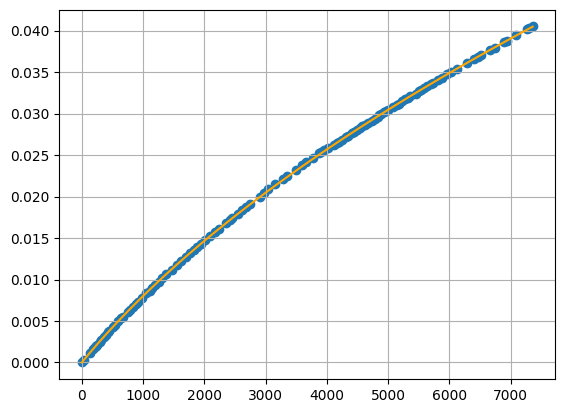

In [28]:
fig, axe = plt.subplots()
axe.scatter(t, xi)
axe.plot(t, yhat, color="orange")
axe.grid()